# What reference level for Stokes drift?

The Stokes drift of a deep-water wave decays exponentially with depth:
$u_\mathrm{St}(z) = A^2 \omega k \exp(2kz)$. When we say a drogued
drifter measures "the current at drogue depth", we implicitly assume
that the Stokes drift contribution equals $u_\mathrm{St}(-l)$ where $l$
is the pole length. But the buoy sits at the instantaneous free surface
$z = \eta(x,t)$, not at mean sea level. Does this matter?

This notebook derives and integrates a Lagrangian mechanics model for
four objects in a monochromatic deep-water wave:

1. **Surface passive tracer** -- constrained to $z = \eta(x,t)$, driven by horizontal drag.
2. **Deep passive tracer** -- a true Lagrangian fluid parcel at initial depth $-l$.
3. **Extended drogued drifter** -- buoy constrained to the free surface, rigid pole to a drogue at depth $\approx -l$.
4. **Production `DroguedDrifter`** -- the operational model from `src/`, driven by the steady Stokes drift profile on a flat surface.

We compare their mean horizontal drifts to Stokes drift predictions
evaluated at different reference levels.

## Physics setup

### Wave field (linear, deep water, monochromatic, progressive in $+x$)

$$\eta(x,t) = A \cos(kx - \omega t)$$
$$u_w(x,z,t) = A\omega \exp(kz) \cos(kx - \omega t)$$
$$w_w(x,z,t) = A\omega \exp(kz) \sin(kx - \omega t)$$

Dispersion: $\omega^2 = gk$. Stokes drift: $u_\mathrm{St}(z) = A^2 \omega k \exp(2kz)$ for $z \le 0$.

### Four objects

**Object 1** (surface tracer): point mass at $z = \eta(x_1, t)$, driven by
horizontal drag $-k_p |(\dot{x}_1 - u_w)| (\dot{x}_1 - u_w)$. Single DOF: $x_1$.

**Object 2** (deep tracer): Lagrangian fluid parcel at initial depth $-l$.
$\dot{x}_2 = u_w(x_2, z_2, t)$, $\dot{z}_2 = w_w(x_2, z_2, t)$.

**Object 3** (drogued drifter): buoy at $z_b = \eta(x_b, t)$, rigid pole of
length $l$, drogue at $(x_b + l\sin\theta,\; \eta - l\cos\theta)$.
DOFs: $(x_b, \theta)$. Euler--Lagrange equations from $L = T - V$ with
generalized drag forces.

**Object 4** (production `DroguedDrifter`): operational model from `src/`,
driven by the steady Stokes drift profile on a flat surface.

In [1]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [2]:
# Symbolic wave field

t = dynamicsymbols._t
A_s, k_s, omega_s, g_s = sp.symbols("A k omega g", positive=True)
x_s, z_s = sp.symbols("x z", real=True)

eta_sym = A_s * sp.cos(k_s * x_s - omega_s * t)
u_w_sym = A_s * omega_s * sp.exp(k_s * z_s) * sp.cos(k_s * x_s - omega_s * t)
w_w_sym = A_s * omega_s * sp.exp(k_s * z_s) * sp.sin(k_s * x_s - omega_s * t)
u_St_sym = A_s**2 * omega_s * k_s * sp.exp(2 * k_s * z_s)

eta_label, u_w_label, w_w_label, u_St_label = sp.symbols("eta u_w w_w u_St")
display(sp.Eq(eta_label, eta_sym, evaluate=False))
display(sp.Eq(u_w_label, u_w_sym, evaluate=False))
display(sp.Eq(w_w_label, w_w_sym, evaluate=False))
display(sp.Eq(u_St_label, u_St_sym, evaluate=False))


Eq(eta, A*cos(k*x - omega*t))

Eq(u_w, A*omega*exp(k*z)*cos(k*x - omega*t))

Eq(w_w, A*omega*exp(k*z)*sin(k*x - omega*t))

Eq(u_St, A**2*k*omega*exp(2*k*z))

## Lagrangian derivation for the extended drogued drifter (Object 3)

The buoy is constrained to the free surface: $z_b = \eta(x_b, t)$.
The drogue hangs from the buoy on a rigid pole of length $l$ at tilt
angle $\theta$ from vertical. Degrees of freedom: $q = (x_b, \theta)$.

Positions:
$$\mathbf{r}_b = (x_b,\; \eta(x_b, t))$$
$$\mathbf{r}_d = (x_b + l\sin\theta,\; \eta(x_b, t) - l\cos\theta)$$

The vertical buoy velocity follows from the constraint:
$$\dot{z}_b = \frac{\partial\eta}{\partial x}\dot{x}_b + \frac{\partial\eta}{\partial t}$$

In [3]:
# Generalized coordinates
x_b = dynamicsymbols("x_b")
theta = dynamicsymbols("theta")

# Physical parameters
m_b, m_d, l_s = sp.symbols("m_b m_d l", positive=True)
m_hat_d = sp.Symbol("m_hat_d", positive=True)
m_tilde_d = sp.Symbol("m_tilde_d", positive=True)
m_tilde_b = sp.Symbol("m_tilde_b", positive=True)
k_b_s, k_d_s = sp.symbols("k_b k_d", positive=True)

# Wave velocity symbols at buoy and drogue positions (substituted numerically later)
U_b_s, W_b_s = sp.symbols("U_b W_b", real=True)
U_d_s, W_d_s = sp.symbols("U_d W_d", real=True)

# Surface elevation at buoy: eta(x_b, t)
# We keep eta as a generic function of x_b and t for the symbolic derivation,
# then substitute the wave field numerically.
eta_b = A_s * sp.cos(k_s * x_b - omega_s * t)

# Buoy position
z_b = eta_b
r_b = sp.Matrix([x_b, z_b])

# Buoy velocity (z_b depends on x_b and t through the constraint)
v_b = r_b.diff(t)

# Drogue position
x_d_expr = x_b + l_s * sp.sin(theta)
z_d_expr = z_b - l_s * sp.cos(theta)
r_d = sp.Matrix([x_d_expr, z_d_expr])

# Drogue velocity
v_d = r_d.diff(t)

display(sp.Eq(sp.Symbol(r'\dot{r}_b', commutative=False), v_b, evaluate=False))
display(sp.Eq(sp.Symbol(r'\dot{r}_d', commutative=False), v_d, evaluate=False))


Eq(\dot{r}_b, Matrix([
[                                       Derivative(x_b(t), t)],
[-A*(k*Derivative(x_b(t), t) - omega)*sin(k*x_b(t) - omega*t)]]))

Eq(\dot{r}_d, Matrix([
[                                       l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t)],
[-A*(k*Derivative(x_b(t), t) - omega)*sin(k*x_b(t) - omega*t) + l*sin(theta(t))*Derivative(theta(t), t)]]))

In [4]:
# Kinetic energy
# T = 1/2 (m_b + m_tilde_b)(xdot_b^2 + zdot_b^2)
#   + 1/2 m_d (xdot_d^2 + zdot_d^2)
#   + 1/2 m_tilde_d xdot_d^2
T = (
    sp.Rational(1, 2) * (m_b + m_tilde_b) * v_b.dot(v_b)
    + sp.Rational(1, 2) * m_d * v_d.dot(v_d)
    + sp.Rational(1, 2) * m_tilde_d * v_d[0]**2
)

# Potential energy
V_pot = m_b * g_s * z_b + (m_d - m_hat_d) * g_s * z_d_expr

# Lagrangian
L = T - V_pot

display(sp.Eq(sp.Symbol('L'), L, evaluate=False))


Eq(L, -A*g*m_b*cos(k*x_b(t) - omega*t) - g*(m_d - m_hat_d)*(A*cos(k*x_b(t) - omega*t) - l*cos(theta(t))) + m_d*((-A*(k*Derivative(x_b(t), t) - omega)*sin(k*x_b(t) - omega*t) + l*sin(theta(t))*Derivative(theta(t), t))**2 + (l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))**2)/2 + m_tilde_d*(l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))**2/2 + (m_b/2 + m_tilde_b/2)*(A**2*(k*Derivative(x_b(t), t) - omega)**2*sin(k*x_b(t) - omega*t)**2 + Derivative(x_b(t), t)**2))

In [5]:
# Generalized forces from quadratic drag
# We use symbolic placeholders U_b, W_b, U_d, W_d for wave velocities
# at the buoy and drogue positions. These will be evaluated numerically.

# Drag on buoy: horizontal only (vertical handled by surface constraint)
# F_b_x = -k_b |xdot_b - U_b| (xdot_b - U_b)
# For the symbolic derivation, use sp.sqrt((delta)^2) = |delta|
delta_b_x = v_b[0] - U_b_s
F_b = sp.Matrix([-k_b_s * sp.sqrt(delta_b_x**2) * delta_b_x, 0])

# Drag on drogue: horizontal only (crossed plates are edge-on vertically)
delta_d_x = v_d[0] - U_d_s
F_d = sp.Matrix([
    -k_d_s * sp.sqrt(delta_d_x**2) * delta_d_x,
    0,
])

# Generalized coordinates
q = sp.Matrix([x_b, theta])
qd = q.diff(t)
qdd = qd.diff(t)

# Generalized forces: Q_i = dr_b/dq_i . F_b + dr_d/dq_i . F_d
Q = sp.Matrix([
    r_b.diff(qi).dot(F_b) + r_d.diff(qi).dot(F_d)
    for qi in q
])

display(sp.Eq(sp.Symbol('Q'), Q, evaluate=False))


Eq(Q, Matrix([
[-k_b*(-U_b + Derivative(x_b(t), t))*sqrt((-U_b + Derivative(x_b(t), t))**2) - k_d*(-U_d + l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))*sqrt((-U_d + l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))**2)],
[                                                             -k_d*l*(-U_d + l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))*sqrt((-U_d + l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))**2)*cos(theta(t))]]))

In [6]:
# Euler-Lagrange equations: d/dt(dL/dqdot_i) - dL/dq_i = Q_i
eoms = sp.Matrix([
    L.diff(qdj).diff(t) - L.diff(qj) - Qj
    for qj, qdj, Qj in zip(q, qd, Q)
])

# Extract mass matrix M and force vector F: M * qdd = -F_rhs
# (linear_eq_to_matrix gives M*qdd = rhs, where rhs = -F from eoms = 0)
M_sym, F_rhs = sp.linear_eq_to_matrix(eoms, list(qdd))

# linear_eq_to_matrix(eoms, qdd) returns (M, F) such that M*qdd = F.
F_sym = F_rhs

display(sp.Eq(sp.Symbol('M'), M_sym, evaluate=False))
display(sp.Eq(sp.Symbol('F'), F_sym, evaluate=False))


Eq(M, Matrix([
[m_d*(2*A**2*k**2*sin(k*x_b(t) - omega*t)**2 + 2)/2 + m_tilde_d + (m_b/2 + m_tilde_b/2)*(2*A**2*k**2*sin(k*x_b(t) - omega*t)**2 + 2), l*m_tilde_d*cos(theta(t)) + m_d*(-2*A*k*l*sin(k*x_b(t) - omega*t)*sin(theta(t)) + 2*l*cos(theta(t)))/2],
[                             l*m_tilde_d*cos(theta(t)) + m_d*(-2*A*k*l*sin(k*x_b(t) - omega*t)*sin(theta(t)) + 2*l*cos(theta(t)))/2,            l**2*m_tilde_d*cos(theta(t))**2 + m_d*(2*l**2*sin(theta(t))**2 + 2*l**2*cos(theta(t))**2)/2]]))

Eq(F, Matrix([
[-2*A**2*k*(m_b/2 + m_tilde_b/2)*(k*Derivative(x_b(t), t) - omega)**2*sin(k*x_b(t) - omega*t)*cos(k*x_b(t) - omega*t) + A*g*k*m_b*sin(k*x_b(t) - omega*t) + A*g*k*(m_d - m_hat_d)*sin(k*x_b(t) - omega*t) - A*k*m_d*(k*Derivative(x_b(t), t) - omega)*(-A*(k*Derivative(x_b(t), t) - omega)*sin(k*x_b(t) - omega*t) + l*sin(theta(t))*Derivative(theta(t), t))*cos(k*x_b(t) - omega*t) - k_b*(-U_b + Derivative(x_b(t), t))*sqrt((-U_b + Derivative(x_b(t), t))**2) - k_d*(-U_d + l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))*sqrt((-U_d + l*cos(theta(t))*Derivative(theta(t), t) + Derivative(x_b(t), t))**2) + l*m_tilde_d*sin(theta(t))*Derivative(theta(t), t)**2 - m_d*(-2*A*k*(k*Derivative(x_b(t), t) - omega)*(-A*(k*Derivative(x_b(t), t) - omega)*sin(k*x_b(t) - omega*t) + l*sin(theta(t))*Derivative(theta(t), t))*cos(k*x_b(t) - omega*t) - 2*A*k*(-A*(k*Derivative(x_b(t), t) - omega)**2*cos(k*x_b(t) - omega*t) + l*cos(theta(t))*Derivative(theta(t), t)**2)*sin(k*x_b(t) - omega*

In [7]:
# Lambdify M and F with sp.lambdify (simple, no CSE)

xb_s, th_s   = sp.symbols("xb th", real=True)
xbd_s, thd_s = sp.symbols("xbd thd", real=True)
t_s           = sp.Symbol("t_s", real=True)

static_subs = {
    x_b: xb_s, theta: th_s,
    x_b.diff(t): xbd_s, theta.diff(t): thd_s,
    t: t_s,
}

M_static = M_sym.subs(static_subs)
F_static = F_sym.subs(static_subs)

arg_syms = (
    xb_s, th_s, xbd_s, thd_s, t_s,
    A_s, k_s, omega_s, g_s,
    m_b, m_d, m_hat_d, m_tilde_d, m_tilde_b, l_s,
    k_b_s, k_d_s,
    U_b_s, W_b_s, U_d_s, W_d_s,
)

M_func = sp.lambdify(arg_syms, M_static, modules="numpy")
F_func = sp.lambdify(arg_syms, F_static, modules="numpy")

print("Lambdified M (2×2) and F (2×1).")


Lambdified M (2×2) and F (2×1).


In [8]:
# Parameters (primitives only — papermill can override these)

# Drifter (matches DroguedDrifter defaults)
P_m_b = 1.0
P_m_d = 2.7
P_m_hat_d = 1.0
P_m_tilde_d = 101.0
P_m_tilde_b = 1.9
P_l = 3.0
P_g = 9.81
P_k_b = 12.0
P_k_d = 154.0

# Wave:
P_Tp = 3.2         # period [s]
P_Hs = 1.0         # significant wave height [m]

# Phase offset so that eta(0, 0) = 0 (neutral/zero-crossing phase)
PHASE_OFFSET = np.pi / 2  # [rad]

# Integration
T_END = 200.0

# Orbital plot
N_orb = 13
T_START = 0.0  # skip initial transient [s]


In [9]:
# Derived quantities and wave field functions

P_A = P_Hs / 2                     # amplitude [m]
P_omega = 2 * np.pi / P_Tp         # angular frequency [rad/s]
P_k = P_omega**2 / P_g             # deep-water wavenumber [1/m]
T_PHASE = PHASE_OFFSET / P_omega   # equivalent time shift = T/4 [s]
dt_out = P_Tp / 60                 # output time step [s]
t_eval = np.arange(0, T_END, dt_out)

print(f"Wave: A = {P_A:.3f} m, T = {P_Tp} s, k = {P_k:.4f} /m")
print(f"Stokes drift at z=0:  {P_A**2 * P_omega * P_k:.4f} m/s")
print(f"Stokes drift at z=-l: {P_A**2 * P_omega * P_k * np.exp(-2 * P_k * P_l):.4f} m/s")
print(f"Phase offset: {PHASE_OFFSET:.4f} rad  (T_PHASE = {T_PHASE:.3f} s = T/4)")
print(f"eta(0, 0) = {P_A * np.cos(PHASE_OFFSET):.6f} m  (should be 0)")

def eta_num(x, t):
    return P_A * np.cos(P_k * x - P_omega * t + PHASE_OFFSET)

def u_w_num(x, z, t):
    return P_A * P_omega * np.exp(P_k * z) * np.cos(P_k * x - P_omega * t + PHASE_OFFSET)

def w_w_num(x, z, t):
    return P_A * P_omega * np.exp(P_k * z) * np.sin(P_k * x - P_omega * t + PHASE_OFFSET)


Wave: A = 0.500 m, T = 3.2 s, k = 0.3930 /m
Stokes drift at z=0:  0.1929 m/s
Stokes drift at z=-l: 0.0183 m/s
Phase offset: 1.5708 rad  (T_PHASE = 0.800 s = T/4)
eta(0, 0) = 0.000000 m  (should be 0)


## Object 1: Surface passive tracer

A point mass constrained to the instantaneous free surface $z = \eta(x_1, t)$.
The horizontal wave drag is evaluated at the **free surface** $z = \eta$, not at
MSL $z=0$. With strong drag this approximates the surface Lagrangian trajectory;
its mean drift approaches $u_\mathrm{St}(0) = A^2 \omega k$ (the surface Stokes
drift, referenced to MSL as per linear wave theory).

In [10]:
# Object 1: surface passive tracer
# EOM: m_p * x_ddot = -k_p * |xdot - u_w(x, eta(x,t), t)| * (xdot - u_w)
# We use state = [x, xdot] and strong drag (k_p large relative to m_p)
# to make it track the surface Lagrangian trajectory closely.

half = t_eval > T_END / 2

m_p = 1.0
k_p = 1000.0  # strong drag to track the wave closely

def rhs_surface_tracer(t, y):
    x, xdot = y
    z = eta_num(x, t)
    u = u_w_num(x, z, t)
    delta = xdot - u
    drag = -k_p * abs(delta) * delta
    xddot = drag / m_p
    return [xdot, xddot]

sol_surf = solve_ivp(
    rhs_surface_tracer, [0, T_END], [0.0, 0.0],
    t_eval=t_eval, rtol=1e-10, atol=1e-12,
)
x_surf = sol_surf.y[0]
xdot_surf = sol_surf.y[1]
z_surf = np.array([eta_num(x, t) for x, t in zip(x_surf, t_eval)])

# Verify: mean drift should approach Stokes drift at z=0
u_St_0 = P_A**2 * P_omega * P_k
mean_drift_surf = (x_surf[half][-1] - x_surf[half][0]) / (t_eval[half][-1] - t_eval[half][0])
print(f"Object 1 mean drift (2nd half): {mean_drift_surf:.6f} m/s")
print(f"Stokes drift at z = 0: {u_St_0:.6f} m/s")
print(f"Relative error: {abs(mean_drift_surf - u_St_0) / u_St_0:.2e}")

Object 1 mean drift (2nd half): 0.203962 m/s
Stokes drift at z = 0: 0.192913 m/s
Relative error: 5.73e-02


## Object 2: Deep passive tracer (Lagrangian fluid parcel at z = −l)

A passive fluid parcel initialized at mean depth $z = -l$ (MSL reference).
It follows the wave velocity exactly: $\dot{x} = u_w(x,z,t)$, $\dot{z} = w_w(x,z,t)$.

The orbit center is at $z = -l$ because the Lagrangian mean depth equals the initial
depth to leading order. The Stokes drift is $u_\mathrm{St}(-l) = A^2\omega k\,e^{-2kl}$.

The relevant question for the drogued drifter is whether the drogue's effective depth
is $-l$ (MSL reference) or $\eta(t) - l$ (free-surface reference). The difference
is $\eta(t)$, which has zero mean but nonzero RMS — so the *time-mean* Stokes drift
seen by the drogue picks up a second-order correction $\propto (kA)^2$.

In [11]:
# Object 2: deep passive tracer at z = -l (MSL reference)

z0_deep = -P_l
print(f'Deep tracer initial z: {z0_deep:.4f} m')

def rhs_deep_tracer(t, y):
    x, z = y
    return [u_w_num(x, z, t), w_w_num(x, z, t)]

sol_deep = solve_ivp(
    rhs_deep_tracer, [0, T_END], [0.0, z0_deep],
    t_eval=t_eval, rtol=1e-10, atol=1e-12,
)
x_deep = sol_deep.y[0]
z_deep = sol_deep.y[1]

u_St_l = P_A**2 * P_omega * P_k * np.exp(-2 * P_k * P_l)
mean_drift_deep = (x_deep[half][-1] - x_deep[half][0]) / (t_eval[half][-1] - t_eval[half][0])
print(f'Object 2 mean drift (2nd half): {mean_drift_deep:.6f} m/s')
print(f'u_St(-l) = {u_St_l:.6f} m/s')
print(f'Relative error: {abs(mean_drift_deep - u_St_l)/u_St_l:.2e}')

Deep tracer initial z: -3.0000 m
Object 2 mean drift (2nd half): 0.019364 m/s
u_St(-l) = 0.018251 m/s
Relative error: 6.10e-02


## Object 3: Extended drogued drifter

The full Lagrangian model with the buoy constrained to the free surface.
State vector: $[x_b, \theta, \dot{x}_b, \dot{\theta}]$. The EOM is
$M \ddot{q} = F$ where $M$ and $F$ come from the lambdified symbolic
derivation above.

In [12]:
# Object 3: extended drogued drifter
# State: [x_b, theta, xb_dot, theta_dot]

def rhs_drifter(t_now, y):
    xb, th, xbd, thd = y

    # Buoy position
    z_b_val = eta_num(xb, t_now)

    # Drogue position
    xd_val = xb + P_l * np.sin(th)
    zd_val = z_b_val - P_l * np.cos(th)

    # Wave velocities at buoy and drogue
    Ub = u_w_num(xb, z_b_val, t_now)
    Wb = w_w_num(xb, z_b_val, t_now)
    Ud = u_w_num(xd_val, zd_val, t_now)
    Wd = w_w_num(xd_val, zd_val, t_now)

    args = (
        xb, th, xbd, thd, t_now - T_PHASE,  # absorb PHASE_OFFSET into time
        P_A, P_k, P_omega, P_g,
        P_m_b, P_m_d, P_m_hat_d, P_m_tilde_d, P_m_tilde_b, P_l,
        P_k_b, P_k_d,
        Ub, Wb, Ud, Wd,
    )

    M_mat = np.array(M_func(*args), dtype=float)     # (2,2)
    F_vec = np.array(F_func(*args), dtype=float).ravel()  # (2,)

    qdd = np.linalg.solve(M_mat, F_vec)
    return [xbd, thd, qdd[0], qdd[1]]

# Initial conditions: buoy at origin, pole hanging straight down (theta=0)
y0_drifter = [0.0, 0.0, 0.0, 0.0]

sol_drifter = solve_ivp(
    rhs_drifter, [0, T_END], y0_drifter,
    t_eval=t_eval, rtol=1e-8, atol=1e-10, method="Radau",
)

x_drifter = sol_drifter.y[0]
theta_drifter = sol_drifter.y[1]
xdot_drifter = sol_drifter.y[2]

# Buoy and drogue z-positions
z_buoy = np.array([eta_num(x, t) for x, t in zip(x_drifter, t_eval)])
z_drogue = z_buoy - P_l * np.cos(theta_drifter)
x_drogue_arr = x_drifter + P_l * np.sin(theta_drifter)  # drogue x position

mean_drift_drifter = (x_drifter[half][-1] - x_drifter[half][0]) / (
    t_eval[half][-1] - t_eval[half][0]
)
print(f"Object 3 mean drift (2nd half): {mean_drift_drifter:.6f} m/s")
print(f"Max theta excursion: {np.degrees(np.max(np.abs(theta_drifter))):.2f} deg")
print(f"O3 mean theta (2nd half): {np.degrees(np.mean(theta_drifter[half])):.2f} deg")

Object 3 mean drift (2nd half): 0.058838 m/s
Max theta excursion: 16.59 deg
O3 mean theta (2nd half): -4.29 deg


## Object 4: DroguedDrifter driven by the Stokes drift profile

The standard operational approach: replace the wave orbital circulation
with a steady Stokes drift profile $u_\mathrm{St}(z) = A^2\omega k\,e^{2kz}$
on a **flat** mean sea level surface ($\eta = 0$, no vertical motion).
This is what `src/drogued_drifters/` does in practice.

The `DroguedDrifter.get_full_solution` method gives the full
time-resolved trajectory. We compare it to Object 3's measured mean drift.

In [13]:
# Object 4: DroguedDrifter from src, driven by steady Stokes profile (flat surface)
from drogued_drifters import DroguedDrifter

def stokes_uv(*, t, x, y, z):
    """Stokes drift profile evaluated at depth z (negative below MSL, z-up convention)."""
    return float(P_A**2 * P_omega * P_k * np.exp(2 * P_k * z)), 0.0

dd = DroguedDrifter(
    m_b=P_m_b,
    m_d=P_m_d,
    m_hat_d=P_m_hat_d,
    m_tilde_d=P_m_tilde_d,
    m_tilde_b=P_m_tilde_b,
    l=P_l,
    k_b=P_k_b,
    k_d=P_k_d,
    g=P_g,
    get_uv=stokes_uv,
)

# Integrate full trajectory
ds4 = dd.get_full_solution(t_span=(0, T_END), t_eval=t_eval)

# Project 3D (theta, phi) to effective 2D pole angle in the x-z plane.
# The 3D pole direction is (sin(theta)*cos(phi), sin(theta)*sin(phi), cos(theta)).
# In the x-z plane, the effective angle is:
theta_o4 = ds4.theta.to_numpy()
phi_o4 = ds4.phi.to_numpy()
theta_xz = np.arctan2(np.sin(theta_o4) * np.cos(phi_o4), np.cos(theta_o4))

# Drogue position from projected angle (2D: x-z plane)
x_o4_buoy = ds4.x.to_numpy()
x_o4_drogue = x_o4_buoy + dd.l * np.sin(theta_xz)
z_o4_drogue = dd.l * np.cos(theta_xz)

# Mean drift from buoy velocity (xd = dx/dt) in second half
half_o4 = t_eval > T_END / 2
mean_drift_dd_stokes = np.mean(ds4.xd.to_numpy()[half_o4])
print(f"Object 4 steady-state drift (DroguedDrifter + Stokes profile): {mean_drift_dd_stokes:.6f} m/s")
print(f"Object 3 mean drift (wave orbitals, extended model):            {mean_drift_drifter:.6f} m/s")
print(f"Difference (O4 - O3): {(mean_drift_dd_stokes - mean_drift_drifter)*1e3:.2f} mm/s")
print(f"O4 mean theta_xz (2nd half): {np.degrees(np.mean(theta_xz[half_o4])):.2f} deg")
print(f"O4 max theta_xz excursion from pi: {np.degrees(np.max(np.abs(theta_xz - np.pi))):.2f} deg")

Object 4 steady-state drift (DroguedDrifter + Stokes profile): 0.056359 m/s
Object 3 mean drift (wave orbitals, extended model):            0.058838 m/s
Difference (O4 - O3): -2.48 mm/s
O4 mean theta_xz (2nd half): -179.24 deg
O4 max theta_xz excursion from pi: 359.99 deg


## Stokes drift at different reference levels

We compute the Stokes drift prediction for the drogued drifter at
several possible reference depths and compare to the actual mean drift
of Object 3.

In [14]:
# Stokes drift function
def u_St(z):
    return P_A**2 * P_omega * P_k * np.exp(2 * P_k * z)

# Reference levels
z_msl = 0.0                                          # mean sea level
z_drogue_msl = -P_l                                   # drogue at -l from MSL
z_buoy_mean = np.mean(z_buoy[half])                   # mean buoy z
z_drogue_from_buoy = z_buoy_mean - P_l                # drogue at -l from mean buoy
# Depth-weighted average: integral of u_St from z_buoy to z_buoy - l, averaged
# over the integration (second half)
z_buoy_half = z_buoy[half]
z_drogue_half = z_drogue[half]

# Column-averaged Stokes drift: for each timestep, integrate u_St from z_drogue to z_buoy
# u_St_avg = 1/l * integral_{z_d}^{z_b} u_St(z) dz
#          = 1/l * A^2 omega k / (2k) * [exp(2kz)]_{z_d}^{z_b}
#          = A^2 omega / (2l) * [exp(2k*z_b) - exp(2k*z_d)]
u_St_col_each = (P_A**2 * P_omega / (2 * P_l)) * (
    np.exp(2 * P_k * z_buoy_half) - np.exp(2 * P_k * z_drogue_half)
)
u_St_col_avg = np.mean(u_St_col_each)

print("Stokes drift predictions vs drifter mean drift")
print("=" * 65)
print(f"{'Reference level':<40s} {'z [m]':>8s} {'u_St [m/s]':>10s}")
print("-" * 65)
print(f"{'z = 0 (MSL)':<40s} {z_msl:>8.3f} {u_St(z_msl):>10.6f}")
print(f"{'z = -l (drogue depth from MSL)':<40s} {z_drogue_msl:>8.3f} {u_St(z_drogue_msl):>10.6f}")
print(f"{'z = <z_buoy> - l':<40s} {z_drogue_from_buoy:>8.3f} {u_St(z_drogue_from_buoy):>10.6f}")
print(f"{'Column avg [z_d(t), z_b(t)]':<40s} {'--':>8s} {u_St_col_avg:>10.6f}")
print("-" * 65)
print(f"{'Object 1 (surface tracer)':<40s} {'--':>8s} {mean_drift_surf:>10.6f}")
print(f"{'Object 2 (deep tracer at -l)':<40s} {-P_l:>8.3f} {mean_drift_deep:>10.6f}")
print(f"{'Object 3 (drogued drifter, wave orbitals)':<40s} {'--':>8s} {mean_drift_drifter:>10.6f}")
print(f"{'Object 4 (src DD + Stokes profile)':<40s} {'--':>8s} {mean_drift_dd_stokes:>10.6f}")

Stokes drift predictions vs drifter mean drift
Reference level                             z [m] u_St [m/s]
-----------------------------------------------------------------
z = 0 (MSL)                                 0.000   0.192913
z = -l (drogue depth from MSL)             -3.000   0.018251
z = <z_buoy> - l                           -2.940   0.019135
Column avg [z_d(t), z_b(t)]                    --   0.080269
-----------------------------------------------------------------
Object 1 (surface tracer)                      --   0.203962
Object 2 (deep tracer at -l)               -3.000   0.019364
Object 3 (drogued drifter, wave orbitals)       --   0.058838
Object 4 (src DD + Stokes profile)             --   0.056359


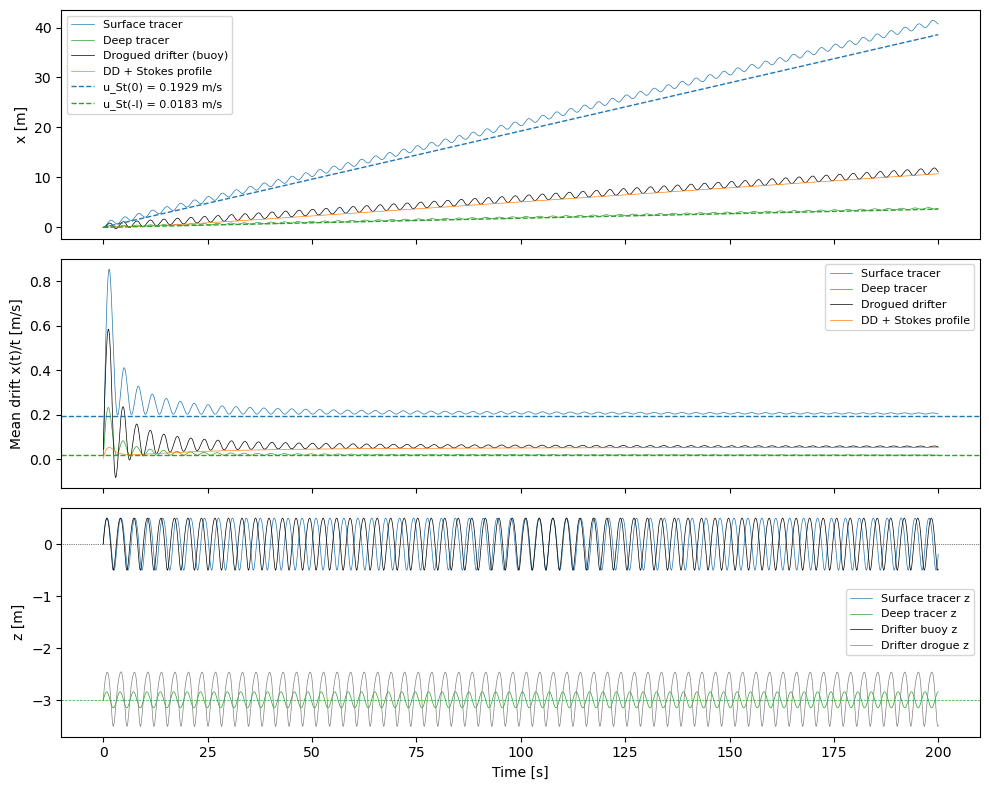

In [15]:
# Plot trajectories and z-positions

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# Panel 1: x-position vs time
ax = axes[0]
ax.plot(t_eval, x_surf, "tab:blue", linewidth=0.5, label="Surface tracer")
ax.plot(t_eval, x_deep, "tab:green", linewidth=0.5, label="Deep tracer")
ax.plot(t_eval, x_drifter, "k", linewidth=0.5, label="Drogued drifter (buoy)")
ax.plot(t_eval, x_o4_buoy, color="tab:orange", linewidth=0.5, label="DD + Stokes profile")
# Reference lines for Stokes drift
ax.plot(t_eval, u_St(0) * t_eval, "tab:blue", linestyle="--", linewidth=1, label=f"u_St(0) = {u_St(0):.4f} m/s")
ax.plot(t_eval, u_St(-P_l) * t_eval, "tab:green", linestyle="--", linewidth=1, label=f"u_St(-l) = {u_St(-P_l):.4f} m/s")
ax.set_ylabel("x [m]")
ax.legend(fontsize=8)

# Panel 2: mean drift velocity x(t)/t
ax = axes[1]
t_nz = t_eval[1:]
ax.plot(t_nz, x_surf[1:] / t_nz, "tab:blue", linewidth=0.5, label="Surface tracer")
ax.plot(t_nz, x_deep[1:] / t_nz, "tab:green", linewidth=0.5, label="Deep tracer")
ax.plot(t_nz, x_drifter[1:] / t_nz, "k", linewidth=0.5, label="Drogued drifter")
ax.plot(t_nz, x_o4_buoy[1:] / t_nz, color="tab:orange", linewidth=0.5, label="DD + Stokes profile")
ax.axhline(u_St(0), color="tab:blue", linestyle="--", linewidth=1)
ax.axhline(u_St(-P_l), color="tab:green", linestyle="--", linewidth=1)
ax.set_ylabel("Mean drift x(t)/t [m/s]")
ax.legend(fontsize=8)

# Panel 3: z-positions
ax = axes[2]
ax.plot(t_eval, z_surf, "tab:blue", linewidth=0.5, label="Surface tracer z")
ax.plot(t_eval, z_deep, "tab:green", linewidth=0.5, label="Deep tracer z")
ax.plot(t_eval, z_buoy, "k", linewidth=0.5, label="Drifter buoy z")
ax.plot(t_eval, z_drogue, color="gray", linewidth=0.5, label="Drifter drogue z")
ax.axhline(0, color="k", linestyle=":", linewidth=0.5)
ax.axhline(-P_l, color="tab:green", linestyle="--", linewidth=0.5)
ax.set_ylabel("z [m]")
ax.set_xlabel("Time [s]")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Orbital trajectories

For a passive fluid parcel at **fixed mean depth** $z_0$, linear wave theory gives circular orbits of radius $A e^{kz_0}$: the horizontal and vertical displacements are both sinusoidal with the same amplitude.

The surface tracer is different. Its vertical position is constrained to $z = \eta(x,t) = A\cos(kx - \omega t)$, so the horizontal wave velocity it experiences is
$$u_w(x, \eta, t) = A\omega\, e^{k\eta}\cos(kx - \omega t).$$
The factor $e^{k\eta}$ is **larger at crests** ($\eta = +A$) and **smaller at troughs** ($\eta = -A$). The tracer therefore moves faster forward (at crests) than backward (at troughs) — this asymmetry is exactly the Stokes drift mechanism, and it also distorts the orbit from a circle into a **prolate trochoid**: the forward arc is wider and faster than the backward arc.

With drift not removed, each object traces a forward-spiraling path. The pitch of the spiral (rightward shift per period) equals the Stokes drift times the wave period.

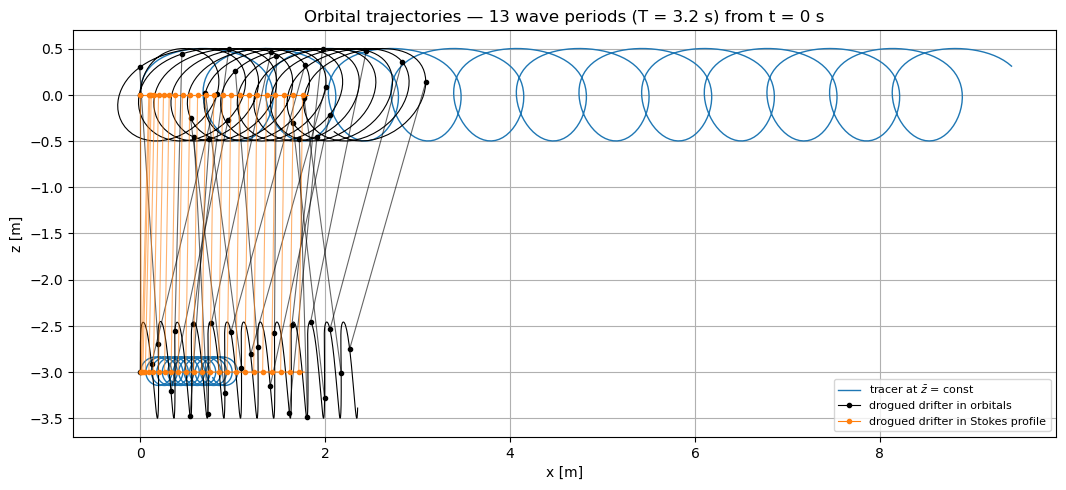

In [16]:
# Orbital plot: N_orb wave periods starting at T_START.
# Drift NOT removed. Trajectories spiral rightward.
# Drogued drifter: O (buoy) --pole-- O (drogue).

i_start = int(np.searchsorted(t_eval, T_START))
i_end   = i_start + int(np.round(N_orb * P_Tp / (t_eval[1] - t_eval[0])))
sl = slice(i_start, i_end)
n_orb = i_end - i_start

x_surf_orb = x_surf[sl]
z_surf_orb = z_surf[sl]

x_deep_orb = x_deep[sl]
z_deep_orb = z_deep[sl]

x_buoy_orb = x_drifter[sl]
z_buoy_orb = z_buoy[sl]
x_drg_orb  = x_drogue_arr[sl]
z_drg_orb  = z_drogue[sl]

x_o4_buoy_orb = x_o4_buoy[sl]
z_o4_buoy_orb = np.zeros(n_orb)
x_o4_drg_orb  = x_o4_drogue[sl]
z_o4_drg_orb  = z_o4_drogue[sl]

fig, ax = plt.subplots(figsize=(12, 5))

# Tracers at constant mean depth (both in blue)
ax.plot(x_surf_orb, z_surf_orb, color='tab:blue', lw=1, label=r'tracer at $\bar{z}$ = const')
ax.plot(x_deep_orb, z_deep_orb, color='tab:blue', lw=1)

# O3: drogued drifter in orbitals — black, solid, 'o' markers
ax.plot(x_buoy_orb, z_buoy_orb, color='k', lw=0.8)
ax.plot(x_drg_orb,  z_drg_orb,  color='k', lw=0.8)

# O4: drogued drifter in Stokes profile — orange, solid, 'o' markers
ax.plot(x_o4_buoy_orb, z_o4_buoy_orb, color='tab:orange', lw=0.8)
ax.plot(x_o4_drg_orb,  z_o4_drg_orb,  color='tab:orange', lw=0.8)

# Pole snapshots — O3
pole_step = max(1, n_orb // 23)
for i in range(0, n_orb, pole_step):
    ax.plot([x_buoy_orb[i], x_drg_orb[i]], [z_buoy_orb[i], z_drg_orb[i]],
            'k-', lw=0.8, alpha=0.6)
    ax.plot(x_buoy_orb[i], z_buoy_orb[i], 'ko', ms=3)
    ax.plot(x_drg_orb[i],  z_drg_orb[i],  'ko', ms=3)
# Single legend entry for O3
ax.plot([], [], 'ko-', lw=0.8, ms=3, label='drogued drifter in orbitals')

# Pole snapshots — O4
for i in range(0, n_orb, pole_step):
    ax.plot([x_o4_buoy_orb[i], x_o4_drg_orb[i]], [z_o4_buoy_orb[i], z_o4_drg_orb[i]],
            '-', color='tab:orange', lw=0.8, alpha=0.6)
    ax.plot(x_o4_buoy_orb[i], z_o4_buoy_orb[i], 'o', color='tab:orange', ms=3)
    ax.plot(x_o4_drg_orb[i],  z_o4_drg_orb[i],  'o', color='tab:orange', ms=3)
# Single legend entry for O4
ax.plot([], [], 'o-', color='tab:orange', lw=0.8, ms=3, label='drogued drifter in Stokes profile')

ax.grid(True)
ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
ax.set_title(f'Orbital trajectories — {N_orb} wave periods (T = {P_Tp} s) from t = {T_START:.0f} s')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()